# Customer Churn Prediction — Iranian Telecom Dataset

This notebook carries out the full process described in `instruct.md` and `PLAN.md`: data cleaning, exploratory analysis, preprocessing, model comparison, threshold selection, risk scoring, feature importance, and business recommendations — end to end, with the reasoning kept next to the code that implements it.

## 1. Setup & raw load

Imports and a first look at the raw file before touching anything.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 100

RAW_PATH = Path("Customer Churn.csv")
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
OUTPUTS_DIR = Path("outputs")
for d in (DATA_DIR, MODELS_DIR, OUTPUTS_DIR):
    d.mkdir(exist_ok=True)

raw = pd.read_csv(RAW_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (3150, 14)


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## 2. Data cleaning

Findings from the initial exploration that drive the cleaning decisions below:

- **300 exact duplicate rows** (~9.5% of the data) — dropped outright, they add no information and would bias training.
- **`Age` is redundant** — every row's `Age` is fully determined by `Age Group` (1→15, 2→25, 3→30, 4→45, 5→55). It's a bucket label dressed up as a number, not a real age. We keep `Age Group` (honestly ordinal) and drop `Age`.
- **Column names have inconsistent double spaces** (`'Call  Failure'`, `'Subscription  Length'`, `'Charge  Amount'`) — normalized to clean snake_case.
- **132 customers (4.2%) are fully dormant**: zero `Seconds of Use`, zero `Frequency of use`, zero `Frequency of SMS`, and `Customer Value` = 0. We don't drop them — a `is_dormant` flag is added instead, since dropping would throw away real customers and their churn behavior is itself informative (52% churn rate among them, vs 15.7% overall).
- No missing values anywhere in the raw file.

In [2]:
rename_map = {
    "Call  Failure": "call_failure",
    "Complains": "complains",
    "Subscription  Length": "subscription_length",
    "Charge  Amount": "charge_amount",
    "Seconds of Use": "seconds_of_use",
    "Frequency of use": "frequency_of_use",
    "Frequency of SMS": "frequency_of_sms",
    "Distinct Called Numbers": "distinct_called_numbers",
    "Age Group": "age_group",
    "Tariff Plan": "tariff_plan",
    "Status": "status",
    "Age": "age",
    "Customer Value": "customer_value",
    "Churn": "churn",
}
df = raw.rename(columns=rename_map)

n_before = len(df)
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# Age is fully determined by age_group -- verify before dropping
assert df.groupby("age_group")["age"].nunique().max() == 1, \
    "age is no longer a 1:1 function of age_group -- investigate before dropping"
df = df.drop(columns=["age"])

df["is_dormant"] = (
    (df["seconds_of_use"] == 0)
    & (df["frequency_of_use"] == 0)
    & (df["frequency_of_sms"] == 0)
    & (df["customer_value"] == 0)
).astype(int)

df.to_csv(DATA_DIR / "customer_churn_cleaned.csv", index=False)

print(f"Rows before: {n_before}")
print(f"Exact duplicates removed: {n_dupes}")
print(f"Rows after: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Dormant customers flagged: {df['is_dormant'].sum()} ({df['is_dormant'].mean():.1%})")
print(f"Churn rate after cleaning: {df['churn'].mean():.1%}")
df.head()

Rows before: 3150
Exact duplicates removed: 300
Rows after: 2850
Columns: ['call_failure', 'complains', 'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'age_group', 'tariff_plan', 'status', 'customer_value', 'churn', 'is_dormant']
Dormant customers flagged: 85 (3.0%)
Churn rate after cleaning: 15.6%


,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,customer_value,churn,is_dormant
0,8,0,38,0,4370,71,5,17,3,1,1,197.640,0,0
1,0,0,39,0,318,5,7,4,2,1,2,46.035,0,0
2,10,0,37,0,2453,60,359,24,3,1,1,1536.520,0,0
3,10,0,38,0,4198,66,1,35,1,1,1,240.020,0,0
4,3,0,38,0,2393,58,2,33,1,1,1,145.805,0,0


## 3. Exploratory Data Analysis

`instruct.md` asks us to analyze: call failures, subscription length, customer value, charge amount, complaints, age, and frequency of service usage. We look at each against churn below, then a full correlation table, then an explicit note on `status`.

In [3]:
overall_churn = df["churn"].mean()
print(f"Overall churn rate: {overall_churn:.1%}\n")

print("Churn rate by complaint status:")
print(df.groupby("complains")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate by age group (1=youngest ... 5=oldest):")
print(df.groupby("age_group")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate by charge_amount tier:")
print(df.groupby("charge_amount")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate by tariff plan (1=pay-as-you-go, 2=contractual):")
print(df.groupby("tariff_plan")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

Overall churn rate: 15.6%

Churn rate by complaint status:
           churn_rate  count
complains                   
0            0.097710   2620
1            0.826087    230

Churn rate by age group (1=youngest ... 5=oldest):
           churn_rate  count
age_group                   
1            0.000000    112
2            0.170467    921
3            0.164352   1296
4            0.201635    367
5            0.012987    154

Churn rate by charge_amount tier:
               churn_rate  count
charge_amount                   
0                0.237460   1575
1                0.075134    559
2                0.060773    362
3                0.036458    192
4                0.014286     70
5                0.000000     30
6                0.000000     11
7                0.000000     12
8                0.000000     19
9                0.000000     13
10               0.000000      7

Churn rate by tariff plan (1=pay-as-you-go, 2=contractual):
             churn_rate  count
tariff_plan   

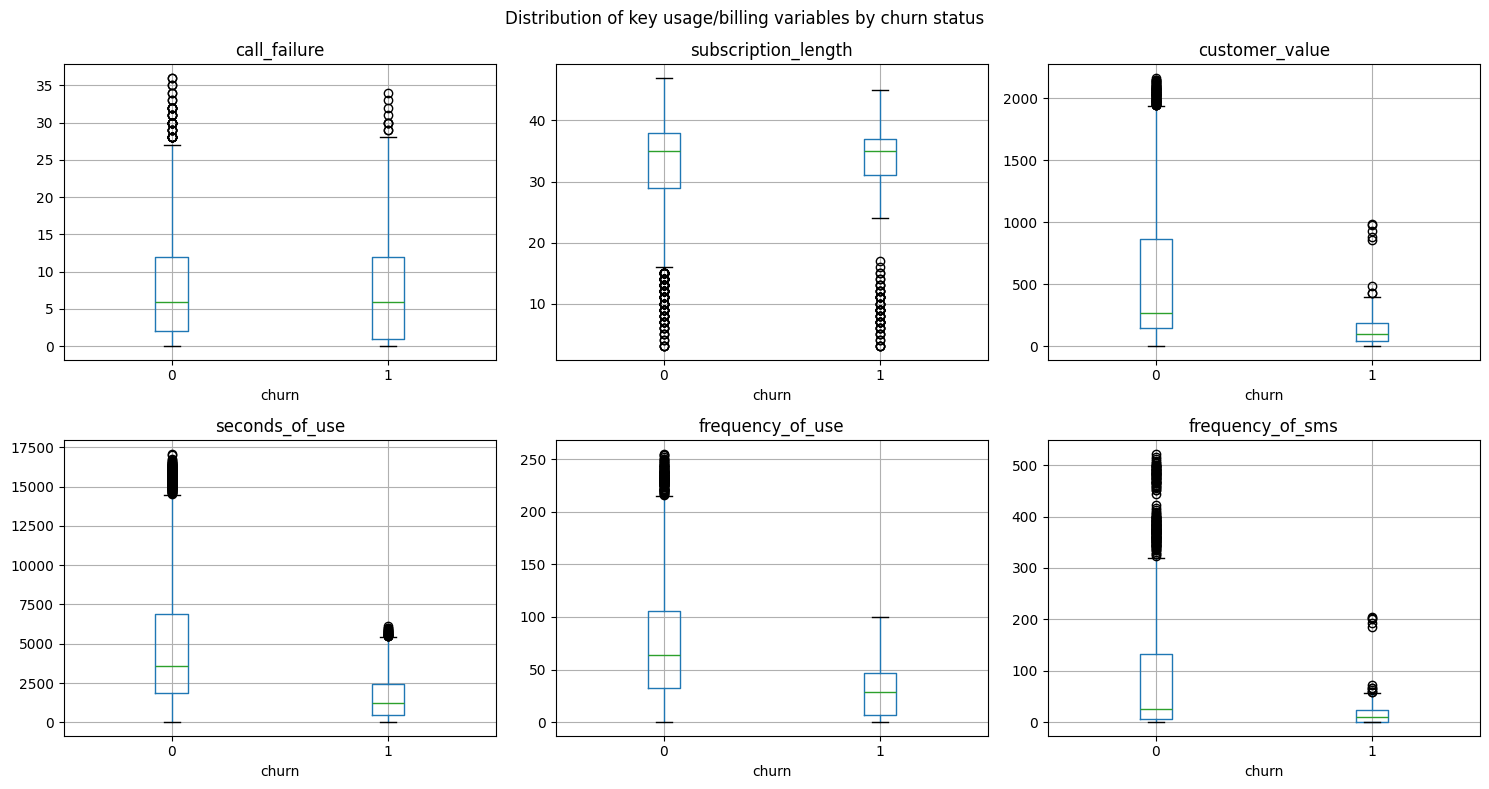


Mean value by churn status:
churn                          0            1
call_failure            7.792013     7.858744
subscription_length    32.595674    31.683857
customer_value        538.590759   132.175695
seconds_of_use       5069.588186  1648.661435
frequency_of_use       77.866473    30.697309
frequency_of_sms       84.353577    16.849776


In [4]:
continuous_vars = [
    "call_failure", "subscription_length", "customer_value",
    "seconds_of_use", "frequency_of_use", "frequency_of_sms",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), continuous_vars):
    df.boxplot(column=col, by="churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("churn")
plt.suptitle("Distribution of key usage/billing variables by churn status")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nMean value by churn status:")
print(df.groupby("churn")[continuous_vars].mean().T)

Correlation of each feature with churn:
churn                      1.000000
complains                  0.546055
status                     0.492867
is_dormant                 0.174288
call_failure               0.003310
age_group                 -0.005891
subscription_length       -0.037984
tariff_plan               -0.106000
charge_amount             -0.201662
frequency_of_sms          -0.218894
distinct_called_numbers   -0.270343
customer_value            -0.287078
seconds_of_use            -0.295999
frequency_of_use          -0.298608
Name: churn, dtype: float64


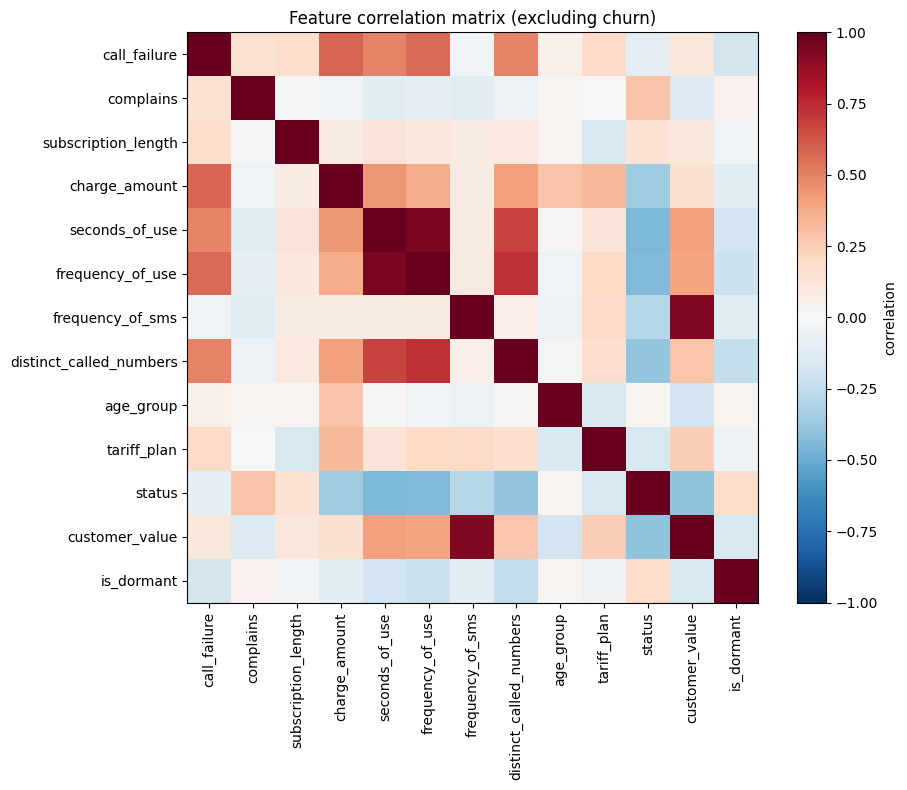


Notable collinearity: frequency_of_use vs seconds_of_use, r = 0.945


In [5]:
corr = df.corr(numeric_only=True)["churn"].sort_values(ascending=False)
print("Correlation of each feature with churn:")
print(corr)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(df.drop(columns=["churn"]).corr(numeric_only=True), cmap="RdBu_r", vmin=-1, vmax=1)
cols = df.drop(columns=["churn"]).columns
ax.set_xticks(range(len(cols)), cols, rotation=90)
ax.set_yticks(range(len(cols)), cols)
plt.colorbar(im, label="correlation")
plt.title("Feature correlation matrix (excluding churn)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nNotable collinearity: frequency_of_use vs seconds_of_use, r =",
      round(df["frequency_of_use"].corr(df["seconds_of_use"]), 3))

### A note on `status`

`status` (1 = active, 2 = non-active) is **not** in instruct.md's list of variables to analyze, and for good reason — it looks like leakage. See below: churn rate is 5% when `status=1` vs ~47% when `status=2`, by far the strongest relationship of any field in the dataset. If `status` reflects an account state that is set at/after the same time churn is determined, including it as a model feature would let the model "cheat" by reading the answer rather than predicting it.

**Decision: `status` is excluded from the model's feature set** (see Section 4), but kept in the cleaned CSV for reference/reporting.

In [6]:
print("Churn rate by status:")
print(df.groupby("status")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate for dormant vs active-usage customers:")
print(df.groupby("is_dormant")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

Churn rate by status:
        churn_rate  count
status                   
1         0.055863   2166
2         0.475146    684

Churn rate for dormant vs active-usage customers:
            churn_rate  count
is_dormant                   
0             0.145389   2765
1             0.517647     85


## 4. Preprocessing

**Feature set**: every cleaned column except `churn` (target) and `status` (excluded per the leakage discussion above). `is_dormant` is kept — it's derived only from usage columns that are already legitimate features, not from the outcome, so it's a useful engineered flag rather than leakage.

**Encoding**: `complains`, `tariff_plan`, `is_dormant` are already binary; `age_group` and `charge_amount` are already meaningful ordinal integers — none need one-hot encoding.

**Scaling**: all features are standardized (mean 0, std 1). Tree models don't need this, but Logistic Regression does, and applying it uniformly keeps one preprocessing pipeline usable for every model.

**Split**: stratified 80/20 train/test split so the ~15.6% churn rate is preserved in both sets, given the class imbalance.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

TARGET = "churn"
EXCLUDED = ["status"]  # leakage risk, see Section 3
FEATURES = [c for c in df.columns if c not in [TARGET] + EXCLUDED]

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), FEATURES)],
    remainder="drop",
)

print("Feature columns used for modeling:", FEATURES)
print(f"\nTrain: {X_train.shape}, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.1%}")

Feature columns used for modeling: ['call_failure', 'complains', 'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'age_group', 'tariff_plan', 'customer_value', 'is_dormant']

Train: (2280, 12), churn rate 15.7%
Test:  (570, 12), churn rate 15.6%


## 5. Modeling

Baseline: Logistic Regression. Compared against Random Forest, XGBoost, and LightGBM, per instruct.md. All four handle the class imbalance (15.6% churn) via class weighting rather than resampling, to avoid synthesizing rows on top of an already small (~2,850-row) dataset.

Each model is wrapped in the same `preprocessor` from Section 4 and evaluated with 5-fold stratified cross-validation on the training set (small dataset → a single train/test split alone is noisy), then refit on the full training set for the held-out test evaluation in Section 6.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1,
    ),
    # n_jobs=1: LightGBM's own multithreading crashes (Windows access-violation)
    # when combined with sklearn's cross_validate on this environment.
    "LightGBM": LGBMClassifier(
        n_estimators=300, is_unbalance=True, random_state=42, n_jobs=1, verbosity=-1,
    ),
}

pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in models.items()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}
    cv_results[name].update({f"{m}_std": scores[f"test_{m}"].std() for m in scoring})

cv_df = pd.DataFrame(cv_results).T
print("5-fold stratified CV results (mean over folds):")
cv_df[["precision", "recall", "f1", "roc_auc"]].round(3)

5-fold stratified CV results (mean over folds):


,precision,recall,f1,roc_auc
Logistic Regression,0.469,0.854,0.605,0.929
Random Forest,0.882,0.697,0.778,0.977
XGBoost,0.832,0.851,0.841,0.978
LightGBM,0.867,0.835,0.850,0.983


## 6. Evaluation on the held-out test set

The 5-fold CV numbers above are useful for comparing models on the training data, but the number instruct.md actually asks for — Precision, Recall, F1, ROC-AUC, and a Confusion Matrix — should be reported on data the model never touched during training or CV. Each pipeline is refit on the full training set and scored once on `X_test`/`y_test`.

In [9]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
)

test_results = {}
fitted_pipelines = {}
test_probas = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    test_probas[name] = proba

    test_results[name] = {
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    }

results_df = pd.DataFrame(test_results).T.round(3)
results_df.to_csv(OUTPUTS_DIR / "model_comparison.csv")
print("Held-out test set performance (threshold = 0.5):")
results_df

Held-out test set performance (threshold = 0.5):


,precision,recall,f1,roc_auc
Logistic Regression,0.438,0.865,0.581,0.914
Random Forest,0.904,0.742,0.815,0.981
XGBoost,0.874,0.854,0.864,0.981
LightGBM,0.884,0.854,0.869,0.986


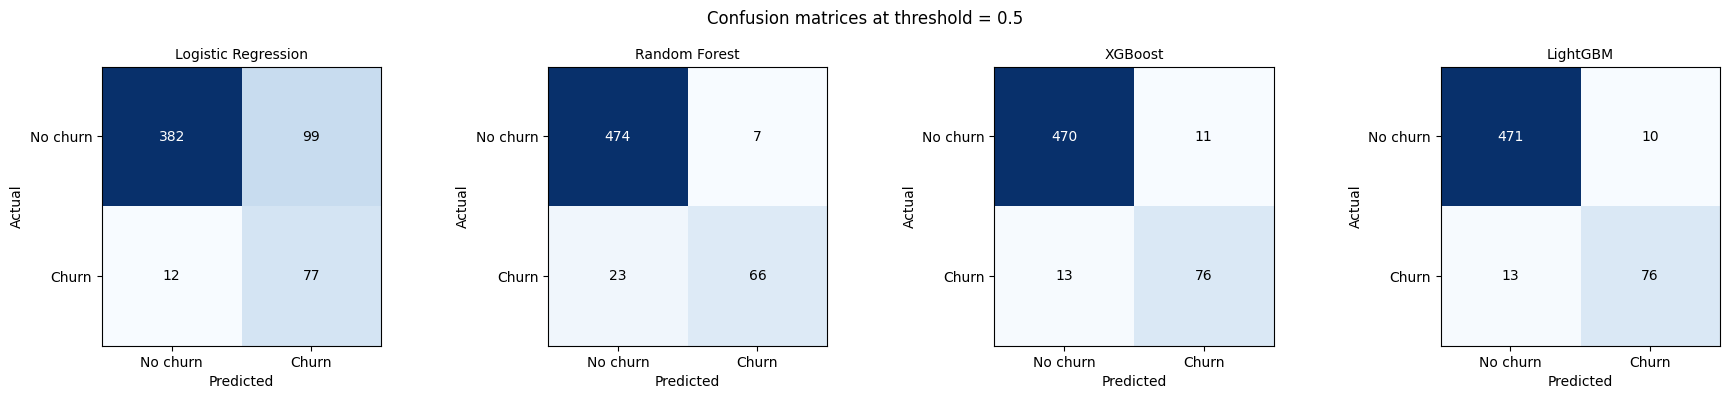

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, pipelines.keys()):
    pred = (test_probas[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["No churn", "Churn"])
    ax.set_yticks([0, 1], ["No churn", "Churn"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.suptitle("Confusion matrices at threshold = 0.5")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
best_model_name = results_df["roc_auc"].idxmax()
best_pipeline = fitted_pipelines[best_model_name]

print(f"Best model by ROC-AUC: {best_model_name}")
print(results_df.loc[best_model_name])
print(
    "\nModel selection rationale: ROC-AUC is used to pick the best model because it "
    "summarizes ranking quality across all thresholds, which matters here since "
    "Section 7 chooses the operating threshold from business costs rather than "
    "defaulting to 0.5. Precision/Recall at the default 0.5 threshold (shown above) "
    "would be a premature basis for model choice -- a model with slightly lower "
    "ROC-AUC but a 'lucky' 0.5 threshold isn't actually better once the threshold "
    "itself becomes a tunable business decision."
)

Best model by ROC-AUC: LightGBM
precision    0.884
recall       0.854
f1           0.869
roc_auc      0.986
Name: LightGBM, dtype: float64

Model selection rationale: ROC-AUC is used to pick the best model because it summarizes ranking quality across all thresholds, which matters here since Section 7 chooses the operating threshold from business costs rather than defaulting to 0.5. Precision/Recall at the default 0.5 threshold (shown above) would be a premature basis for model choice -- a model with slightly lower ROC-AUC but a 'lucky' 0.5 threshold isn't actually better once the threshold itself becomes a tunable business decision.
